<a href="https://colab.research.google.com/github/23424022/Pengolahan-Citra-Digital/blob/main/PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar:


Saving nailong.jpg to nailong.jpg


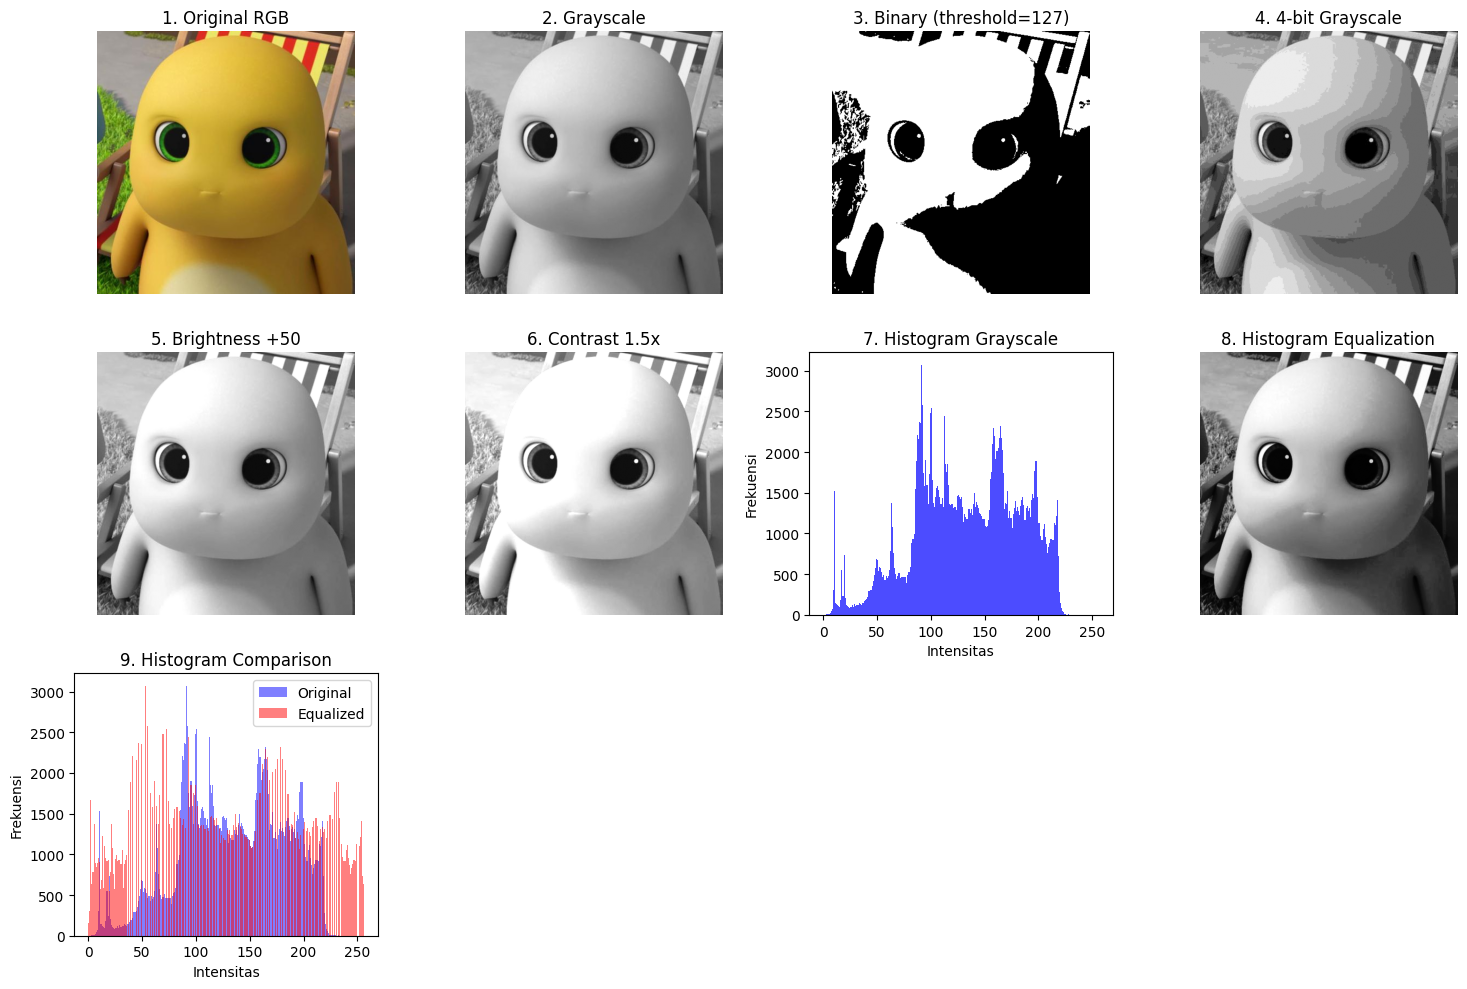


=== INFORMASI GAMBAR ===
Dimensi gambar: (483, 474)
Range nilai grayscale: [0, 232]
Range nilai 4-bit: [0, 224]
Range nilai setelah equalization: [0, 255]

Jalankan demo interaktif? (y/n): y

=== DEMO INTERAKTIF ===
Masukkan threshold untuk biner (0-255): 200
Masukkan nilai m untuk m-bit (1-8): 5


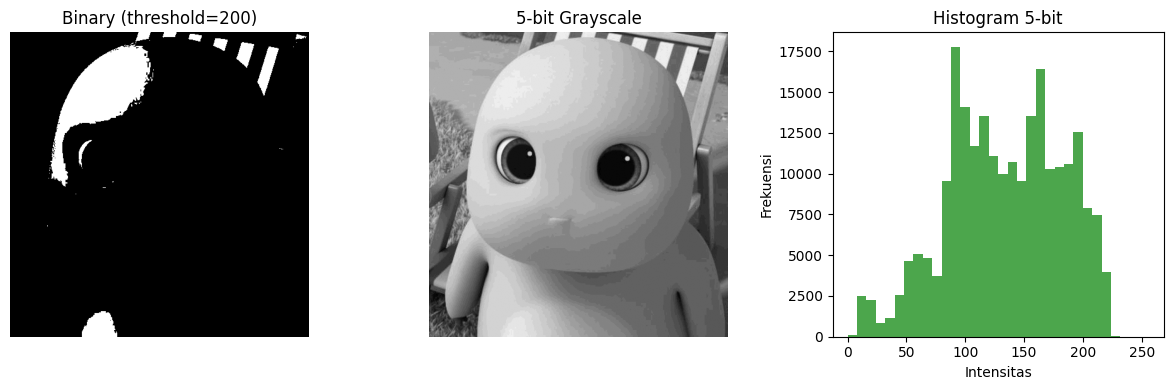

In [4]:
# Import library yang diperlukan
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage import exposure

# Upload gambar
print("Upload gambar:")
uploaded = files.upload()

# Baca gambar yang diupload
for filename in uploaded.keys():
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    break

# 1. Konversi RGB ke Grayscale
def rgb_to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

gray_img = rgb_to_grayscale(img_rgb)

# 2. Konversi Grayscale ke Biner
def grayscale_to_binary(image, threshold=127):
    _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    return binary

binary_img = grayscale_to_binary(gray_img)

# 3. Konversi Grayscale ke m-bit
def grayscale_to_mbit(image, m=4):
    # m-bit quantization (2^m levels)
    levels = 2**m
    step = 256 // levels
    quantized = (image // step) * step
    return quantized.astype(np.uint8)

mbit_img = grayscale_to_mbit(gray_img, m=4)

# 4. Image dengan Brightness
def adjust_brightness(image, brightness_value=50):
    # brightness_value range: -255 to 255
    bright_img = cv2.convertScaleAbs(image, alpha=1, beta=brightness_value)
    return bright_img

bright_img = adjust_brightness(gray_img, brightness_value=50)

# 5. Image dengan Contrast
def adjust_contrast(image, contrast_value=1.5):
    # contrast_value range: 0 to 3 (1 = original)
    contrast_img = cv2.convertScaleAbs(image, alpha=contrast_value, beta=0)
    return contrast_img

contrast_img = adjust_contrast(gray_img, contrast_value=1.5)

# 6. Image Grayscale to Histogram
def plot_histogram(image, title="Histogram"):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Gambar')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(image.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.7)
    plt.title(title)
    plt.xlabel('Intensitas Pixel')
    plt.ylabel('Frekuensi')
    plt.show()

# 7. Image dengan Operasi Histogram Equalization
def histogram_equalization(image):
    return cv2.equalizeHist(image)

equalized_img = histogram_equalization(gray_img)

# Tampilkan semua hasil
plt.figure(figsize=(15, 10))

# Original RGB
plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title('1. Original RGB')
plt.axis('off')

# Grayscale
plt.subplot(3, 4, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('2. Grayscale')
plt.axis('off')

# Binary
plt.subplot(3, 4, 3)
plt.imshow(binary_img, cmap='gray')
plt.title('3. Binary (threshold=127)')
plt.axis('off')

# m-bit (4-bit)
plt.subplot(3, 4, 4)
plt.imshow(mbit_img, cmap='gray')
plt.title('4. 4-bit Grayscale')
plt.axis('off')

# Brightness
plt.subplot(3, 4, 5)
plt.imshow(bright_img, cmap='gray')
plt.title('5. Brightness +50')
plt.axis('off')

# Contrast
plt.subplot(3, 4, 6)
plt.imshow(contrast_img, cmap='gray')
plt.title('6. Contrast 1.5x')
plt.axis('off')

# Histogram Grayscale
plt.subplot(3, 4, 7)
plt.hist(gray_img.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title('7. Histogram Grayscale')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

# Histogram Equalization
plt.subplot(3, 4, 8)
plt.imshow(equalized_img, cmap='gray')
plt.title('8. Histogram Equalization')
plt.axis('off')

# Perbandingan histogram sebelum dan sesudah equalization
plt.subplot(3, 4, 9)
plt.hist(gray_img.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.5, label='Original')
plt.hist(equalized_img.ravel(), bins=256, range=(0, 256), color='red', alpha=0.5, label='Equalized')
plt.title('9. Histogram Comparison')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.legend()

plt.tight_layout()
plt.show()

# Informasi tambahan
print("\n=== INFORMASI GAMBAR ===")
print(f"Dimensi gambar: {gray_img.shape}")
print(f"Range nilai grayscale: [{gray_img.min()}, {gray_img.max()}]")
print(f"Range nilai 4-bit: [{mbit_img.min()}, {mbit_img.max()}]")
print(f"Range nilai setelah equalization: [{equalized_img.min()}, {equalized_img.max()}]")

# Fungsi interaktif untuk mencoba berbagai parameter
def interactive_demo():
    print("\n=== DEMO INTERAKTIF ===")

    # Coba threshold berbeda untuk biner
    thresh = int(input("Masukkan threshold untuk biner (0-255): "))
    binary_custom = grayscale_to_binary(gray_img, thresh)

    # Coba m-bit berbeda
    m = int(input("Masukkan nilai m untuk m-bit (1-8): "))
    mbit_custom = grayscale_to_mbit(gray_img, m)

    # Tampilkan hasil
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(binary_custom, cmap='gray')
    plt.title(f'Binary (threshold={thresh})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mbit_custom, cmap='gray')
    plt.title(f'{m}-bit Grayscale')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.hist(mbit_custom.ravel(), bins=2**m, range=(0, 256), color='green', alpha=0.7)
    plt.title(f'Histogram {m}-bit')
    plt.xlabel('Intensitas')
    plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

# Panggil fungsi demo interaktif jika diinginkan
run_demo = input("\nJalankan demo interaktif? (y/n): ")
if run_demo.lower() == 'y':
    interactive_demo()